# GRUPO 43 — Entrega 5: solución completa

## Stacking de regresión logística, Naive Bayes y Random Forest sobre cláusulas

**Objetivo:** obtener el mayor F1 macro posible con modelos clásicos. En las entregas anteriores llegamos a ≈ 0.89 con dos caminos distintos: TF‑IDF + regresión logística (entrega 2) y Random Forest con variables de polaridad (entrega 4). Esta entrega **combina** lo aprendido.

### Qué cambia respecto a las entregas anteriores

1. **Cláusulas en lugar de oraciones.** Muchas reseñas cambian de opinión **dentro** de una oración: *"la memoria luce buenísima, **pero** la app quedó mal terminada"*. Ahora cortamos también en *pero*, *aunque* y *sin embargo*, y usamos la **última cláusula**.
2. **Conectores como variable.** El conjunto de datos usa conectores fijos al inicio de las opiniones (*eso sí*, *aun así*, *por otro lado*, *de paso*, *por cierto*…). Algunos son **contrastivos** (introducen la opinión que manda) y otros **aditivos** (agregan un comentario de paso). Le damos al modelo qué conector abre cada cláusula para que aprenda esa diferencia.
3. **Ensamble por apilamiento (*stacking*).** Dos modelos de texto (regresión logística y Naive Bayes) generan probabilidades; un Random Forest final las combina con las variables de polaridad y conectores por cláusula.

### Por qué estos modelos

| Modelo | Representación | Qué aporta | Por qué lo incluimos |
|---|---|---|---|
| **Regresión logística** | TF‑IDF (texto completo con bigramas + última cláusula) | Suma la evidencia de miles de palabras a la vez. | Fue el mejor modelo individual sobre texto disperso (entregas 1 y 2). |
| **Naive Bayes multinomial** | BoW binaria (mismas dos vistas) | Modelo probabilístico con supuestos distintos (independencia de palabras). | Comete errores **diferentes** a la regresión logística; esa diversidad es lo que hace útil un ensamble. |
| **Random Forest (meta‑modelo)** | 21 variables de polaridad, opinión y conector por cláusula + probabilidades *out-of-fold* de LR y NB | Aprende reglas no lineales sobre la estructura de la reseña y decide **cuándo confiar** en cada modelo de texto. | En la entrega 4, un Random Forest sobre variables de polaridad fue tan bueno como la regresión logística. Aquí recibe además las probabilidades de LR y NB. Un modelo lineal como meta‑modelo solo podría promediarlas; el árbol puede condicionar (por ejemplo: "si la última cláusula con opinión es claramente negativa, confía en ella aunque LR dude"). |

### Reglas del proyecto (Parte 1)

| Regla | Cómo se cumple |
|---|---|
| Sin aprendizaje profundo, transformers ni *embeddings* preentrenados | Todo sale de conteos de palabras: BoW, TF‑IDF y n‑gramas. |
| Solo clasificadores de scikit-learn | `LogisticRegression`, `MultinomialNB`, `RandomForestClassifier`. El ensamble y el transformador de variables usan `cross_val_predict`, `CountVectorizer` y `Pipeline` de scikit-learn. |
| `eval.csv` no se usa para entrenar | Solo se usa en la última sección para predecir. |
| Resultados replicables | Semillas fijas; todo el código está en este notebook y el modelo se guarda con `joblib`. |

## 1. Preparación del entorno y datos

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
ORDER = ["negativo", "neutral", "positivo"]
COLORS = {"negativo": "#E45756", "neutral": "#9D9D9D", "positivo": "#54A24B"}
DATA_DIR = Path("../data")
Path("models").mkdir(exist_ok=True)

In [2]:
import re, unicodedata
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")
assert eval_df["id"].equals(sample_sub["id"])
print(train_df.shape, eval_df.shape)

(12000, 3) (3000, 2)


### 1.1 División train / validación

Usamos la misma partición estratificada 80/20 de todas las entregas. **Control:** la proporción de clases debe ser igual en ambos conjuntos.

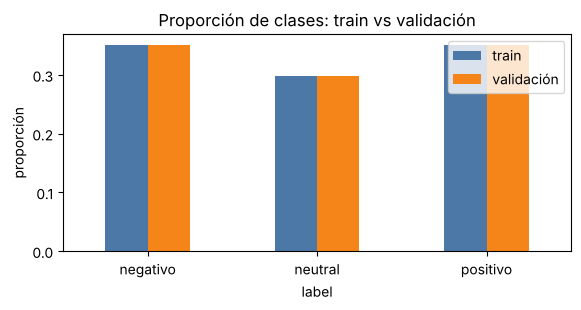

,train,validación
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"], train_df["label"], test_size=0.2, stratify=train_df["label"], random_state=RANDOM_STATE)

prop = pd.DataFrame({"train": y_train.value_counts(normalize=True),
                     "validación": y_val.value_counts(normalize=True)}).reindex(ORDER)
ax = prop.plot(kind="bar", rot=0, figsize=(6, 3.2), color=["#4C78A8", "#F58518"])
ax.set_title("Proporción de clases: train vs validación"); ax.set_ylabel("proporción")
plt.tight_layout(); plt.show()
prop.round(3)

**Qué sale:** proporciones idénticas (≈ 35/30/35). La partición es comparable.

## 2. Preparación del texto: cláusulas y conectores

- `limpiar_texto`: minúsculas, sin tildes y solo letras (igual que en todas las entregas).
- `separar_clausulas`: corta en `.`, `!`, `?` y `;`, y **también** antes de *pero*, *aunque* y *sin embargo*.
- `conector`: identifica con qué conector empieza una cláusula. La lista se armó revisando los inicios de oración más frecuentes en `train.csv`.

In [4]:
def quitar_tildes(t):
    t = unicodedata.normalize("NFKD", t)
    return "".join(c for c in t if not unicodedata.combining(c))

def limpiar_texto(t):
    t = quitar_tildes(str(t).lower())
    t = re.sub(r"[^a-zñ\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def separar_clausulas(t):
    t = re.sub(r"\b(pero|aunque|sin embargo)\b", r". \1", str(t), flags=re.I)
    c = [limpiar_texto(p) for p in re.split(r"[.!?;]+", t)]
    c = [x for x in c if x]
    return c if c else [""]

CONECTORES = ["eso si", "aun asi", "por otro lado", "la verdad", "por cierto", "de paso", "con todo", "ademas",
              "al final", "a fin de cuentas", "ahora", "pero", "aunque", "sin embargo", "en fin", "para mi",
              "en mi opinion", "para ser sincero", "la verdad sea dicha", "hay de todo", "para gustos", "sigo con dudas"]
_ORD = sorted(CONECTORES, key=len, reverse=True)

def conector(c):
    for k in _ORD:
        if c == k or c.startswith(k + " "):
            return CONECTORES.index(k)
    return -1

In [5]:
ejemplo = train_df.loc[train_df["text"].str.contains(", pero"), "text"].iloc[0]
print(ejemplo, "\n")
for c in separar_clausulas(ejemplo):
    k = conector(c)
    print(f"  [{CONECTORES[k] if k >= 0 else '-':>14}]  {c}")

La compré a mediados de año por internet y tardó como una semana en llegar a mi casa, nada fuera de lo normal. La uso todos los días en el celular que llevo al trabajo. La funda fue un error de compra y el botón de encendido vale totalmente la pena. Mi hermano me dijo que él habría elegido otro modelo, pero eso ya es cosa de cada quien. Lo dejo a tu criterio. 

  [             -]  la compre a mediados de ano por internet y tardo como una semana en llegar a mi casa nada fuera de lo normal
  [             -]  la uso todos los dias en el celular que llevo al trabajo
  [             -]  la funda fue un error de compra y el boton de encendido vale totalmente la pena
  [             -]  mi hermano me dijo que el habria elegido otro modelo
  [          pero]  pero eso ya es cosa de cada quien
  [             -]  lo dejo a tu criterio


### 2.1 Control: ¿el conector de la última cláusula se relaciona con la clase?

Si los conectores aportan información, su frecuencia debería cambiar entre clases. En particular, las reseñas neutrales casi no deberían terminar con conectores de opinión.

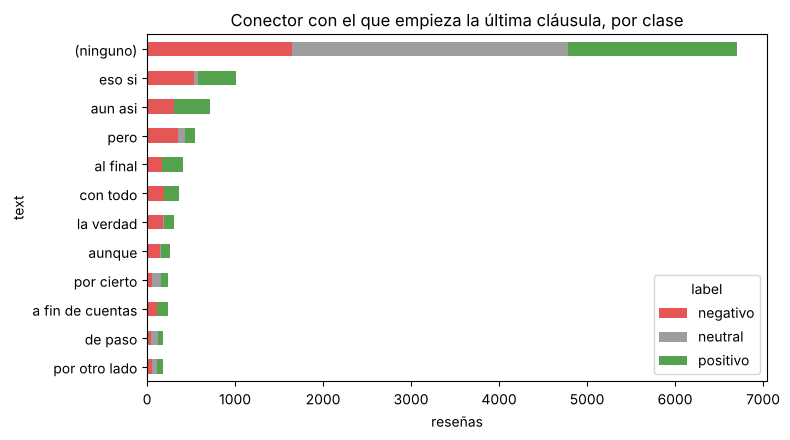

In [6]:
ult_con = train_df["text"].map(lambda t: conector(separar_clausulas(t)[-1]))
tabla = pd.crosstab(ult_con.map(lambda k: CONECTORES[k] if k >= 0 else "(ninguno)"), train_df["label"])
tabla = tabla.loc[tabla.sum(1).sort_values(ascending=False).index[:12]]
ax = tabla[ORDER].plot(kind="barh", stacked=True, figsize=(8, 4.5), color=[COLORS[c] for c in ORDER])
ax.invert_yaxis(); ax.set_title("Conector con el que empieza la última cláusula, por clase"); ax.set_xlabel("reseñas")
plt.tight_layout(); plt.show()

**Qué sale:**
- Los conectores contrastivos (*eso sí*, *aun así*, *al final*, *con todo*, *a fin de cuentas*) casi nunca cierran reseñas neutrales: señalan que la última cláusula es una opinión. En cambio, *pero*, *por cierto*, *de paso* y *por otro lado* sí aparecen en neutrales, porque también se usan para comentarios descriptivos.
- El conector **no dice** por sí solo si la reseña es positiva o negativa (rojo y verde están repartidos). Su valor es indicar **dónde está la opinión**, y por eso necesita combinarse con la polaridad.

## 3. Modelos base

### 3.1 Regresión logística y Naive Bayes sobre texto

Ambos reciben dos vistas de la reseña: el **texto completo** y la **última cláusula**, cada una con su propio vectorizador. LR usa TF‑IDF con bigramas en el texto completo y NB usa BoW binaria. Los hiperparámetros (`C=3` y `alpha=0.5`) salen de las búsquedas de las entregas 1 y 2 y de pruebas rápidas en validación.

In [7]:
def construir_vistas(textos):
    textos = pd.Series(textos).astype(str)
    return pd.DataFrame({"completo": textos.map(limpiar_texto).values,
                         "ultima_clausula": textos.map(lambda t: separar_clausulas(t)[-1]).values})

def vistas_texto(vectorizador_completo, vectorizador_ultima):
    return Pipeline([("vistas", FunctionTransformer(construir_vistas)),
                     ("vec", ColumnTransformer([("completo", vectorizador_completo, "completo"),
                                                ("ultima", vectorizador_ultima, "ultima_clausula")]))])

def modelo_lr(C=3):
    return Pipeline([("texto", vistas_texto(TfidfVectorizer(min_df=2, sublinear_tf=True, ngram_range=(1, 2)),
                                            TfidfVectorizer(min_df=2, sublinear_tf=True))),
                     ("clf", LogisticRegression(C=C, max_iter=4000, random_state=42))])

def modelo_nb(alpha=0.5):
    return Pipeline([("texto", vistas_texto(CountVectorizer(min_df=2, binary=True, ngram_range=(1, 2)),
                                            CountVectorizer(min_df=2, binary=True))),
                     ("clf", MultinomialNB(alpha=alpha))])

### 3.2 Variables de polaridad y conectores por cláusula

Es la idea de la entrega 4, ahora por cláusula y con el conector de cada una. Estas variables alimentan al meta‑modelo; además, como referencia, medimos qué logra un Random Forest usando **solo** estas variables (`modelo_rf`). Para cada reseña se calculan 21 variables:
- para las últimas 4 cláusulas: **polaridad** (positivo vs negativo), **opinión** (opinión vs neutral) y **conector**;
- polaridad y conector de la última y la penúltima cláusula **con opinión**;
- totales y conteos.

Los pesos de cada palabra son log‑cocientes de frecuencias de la bolsa de palabras (con suavizado +1, como en Naive Bayes). En entrenamiento las variables se calculan *out-of-fold* para no filtrar la etiqueta.

In [8]:
class PolaridadClausulas(BaseEstimator, TransformerMixin):
    def __init__(self, n_posiciones=4, n_folds=5, random_state=42):
        self.n_posiciones = n_posiciones; self.n_folds = n_folds; self.random_state = random_state

    @staticmethod
    def _log_ratio(vec, textos, ma, mb):
        X = vec.transform(textos)
        a = np.asarray(X[ma].sum(0)).ravel() + 1
        b = np.asarray(X[mb].sum(0)).ravel() + 1
        return np.log(a / a.sum()) - np.log(b / b.sum())

    def _aprender(self, cl, y):
        y = np.asarray(y)
        ultimas = [c[-1] for c in cl]; completos = [" ".join(c) for c in cl]
        vp = CountVectorizer(binary=True, min_df=2).fit(ultimas)
        vo = CountVectorizer(binary=True, min_df=2).fit(completos)
        return vp, self._log_ratio(vp, ultimas, y == "positivo", y == "negativo"), \
               vo, self._log_ratio(vo, completos, y != "neutral", y == "neutral")

    def _features(self, cl, pesos):
        vp, wp, vo, wo = pesos
        filas = []
        for c in cl:
            pol = vp.transform(c) @ wp; op = vo.transform(c) @ wo
            f = []
            for k in range(1, self.n_posiciones + 1):
                f += [pol[-k], op[-k], conector(c[-k])] if len(c) >= k else [0.0, -99.0, -2]
            j = np.where(op > 0)[0]
            f += [pol[j[-1]] if len(j) else 0.0, conector(c[j[-1]]) if len(j) else -2,
                  pol[j[-2]] if len(j) > 1 else 0.0, conector(c[j[-2]]) if len(j) > 1 else -2,
                  op.max(), op.sum(), pol.sum(), len(c), len(j)]
            filas.append(f)
        return np.array(filas, dtype=float)

    def nombres(self):
        n = []
        for k in range(self.n_posiciones):
            n += [f"pol_ult-{k}", f"op_ult-{k}", f"con_ult-{k}"]
        return n + ["pol_ult_opinion", "con_ult_opinion", "pol_penult_opinion", "con_penult_opinion",
                    "op_max", "op_total", "pol_total", "n_clausulas", "n_con_opinion"]

    def fit(self, X, y):
        self.pesos_ = self._aprender([separar_clausulas(t) for t in X], y); return self

    def transform(self, X):
        return self._features([separar_clausulas(t) for t in X], self.pesos_)

    def fit_transform(self, X, y):
        cl = [separar_clausulas(t) for t in X]; y = np.asarray(y)
        F = np.zeros((len(cl), 3 * self.n_posiciones + 9))
        for i1, i2 in StratifiedKFold(self.n_folds, shuffle=True, random_state=self.random_state).split(cl, y):
            F[i2] = self._features([cl[i] for i in i2], self._aprender([cl[i] for i in i1], y[i1]))
        self.pesos_ = self._aprender(cl, y)
        return F

def modelo_rf(leaf=3):
    return Pipeline([("polaridad", PolaridadClausulas(random_state=42)),
                     ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=leaf, n_jobs=-1, random_state=42))])

### 3.3 Desempeño individual de los modelos base

In [9]:
base = {"Regresión logística": modelo_lr(), "Naive Bayes": modelo_nb(), "Random Forest (polaridad)": modelo_rf()}
pred_base = {}
for nombre, m in base.items():
    pred_base[nombre] = m.fit(X_train, y_train).predict(X_val)
res_base = pd.DataFrame({n: {"accuracy": accuracy_score(y_val, p), "F1 macro": f1_score(y_val, p, average="macro")}
                         for n, p in pred_base.items()}).T
res_base.round(4)

,accuracy,F1 macro
Regresión logística,0.8967,0.9009
Naive Bayes,0.8329,0.8405
Random Forest (polaridad),0.8992,0.9038


### 3.4 Control: ¿los modelos se equivocan en reseñas distintas?

Un ensamble solo mejora si los modelos **no** se equivocan en lo mismo. Incluimos el Random Forest de polaridad como representante de la información que aportan las variables de polaridad y conectores. Contamos cuántos errores de validación comparte cada par de modelos y cuántos errores serían "rescatables", es decir, al menos un modelo acierta.

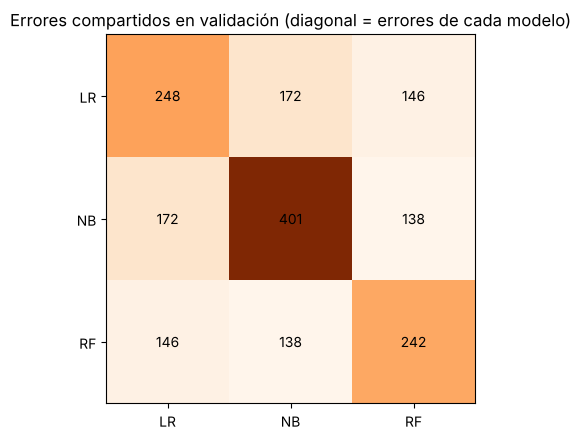

Reseñas con al menos un modelo equivocado: 539 | todos equivocados: 104
-> En 435 reseñas al menos un modelo acierta: es el margen que el ensamble puede aprovechar.


In [10]:
err = pd.DataFrame({n: (p != y_val.values) for n, p in pred_base.items()})
nombres = list(err.columns)
comp = pd.DataFrame([[ (err[a] & err[b]).sum() for b in nombres] for a in nombres], index=nombres, columns=nombres)

fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(comp.values, cmap="Oranges")
ax.set_xticks(range(3)); ax.set_xticklabels(["LR", "NB", "RF"]); ax.set_yticks(range(3)); ax.set_yticklabels(["LR", "NB", "RF"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, comp.values[i, j], ha="center", va="center")
ax.set_title("Errores compartidos en validación (diagonal = errores de cada modelo)")
plt.tight_layout(); plt.show()

todos = err.all(axis=1).sum(); alguno = err.any(axis=1).sum()
print(f"Reseñas con al menos un modelo equivocado: {alguno} | todos equivocados: {todos}")
print(f"-> En {alguno - todos} reseñas al menos un modelo acierta: es el margen que el ensamble puede aprovechar.")

**Qué sale:** los errores se solapan solo en parte. Hay cientos de reseñas en las que al menos un modelo acierta, lo que justifica combinarlos. Ese es el margen que buscamos capturar con el *stacking*.

### 3.5 Control: fuga de información en las variables de polaridad

Como en la entrega 4: la distribución de la polaridad de la última cláusula con opinión debe verse igual en train (*out-of-fold*) y en validación.

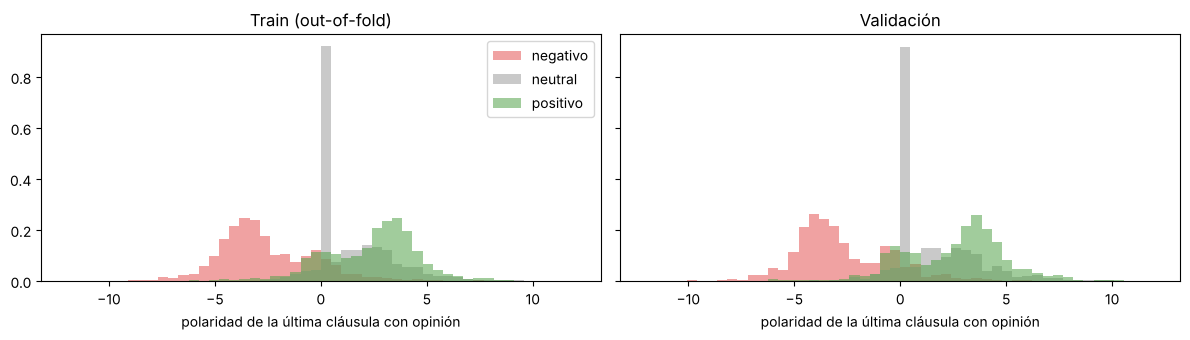

In [11]:
pol = PolaridadClausulas(random_state=RANDOM_STATE)
F_tr, F_va = pol.fit_transform(X_train, y_train), pol.transform(X_val)
col = pol.nombres().index("pol_ult_opinion")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, F, y, t in [(axes[0], F_tr, y_train, "Train (out-of-fold)"), (axes[1], F_va, y_val, "Validación")]:
    for c in ORDER:
        ax.hist(F[np.asarray(y) == c, col], bins=50, range=(-12, 12), alpha=0.55, density=True, color=COLORS[c], label=c)
    ax.set_title(t); ax.set_xlabel("polaridad de la última cláusula con opinión")
axes[0].legend(); plt.tight_layout(); plt.show()

**Qué sale:** las dos distribuciones son prácticamente iguales, así que no hay fuga.

## 4. Ensamble por apilamiento (*stacking*)

**Cómo funciona `StackingPolaridad`:**
1. Con `cross_val_predict` (5 *folds*) obtenemos las probabilidades **out-of-fold** de LR y NB para cada reseña de entrenamiento. Cada probabilidad la calcula un modelo que no vio esa reseña. Esto es clave: si usáramos las probabilidades del modelo entrenado con todos los datos, serían demasiado optimistas y el meta‑modelo aprendería a confiar ciegamente en ellas.
2. Calculamos las 21 variables de polaridad/conectores, también *out-of-fold*.
3. Entrenamos el **Random Forest meta** con esas 21 variables + 3 probabilidades de LR + 3 de NB.
4. Para predecir, LR y NB se reentrenan con todo el set de entrenamiento y sus probabilidades, junto con las variables de polaridad, pasan al meta‑modelo.

*Nota:* scikit-learn trae `StackingClassifier`, pero su meta‑modelo solo recibe probabilidades de los modelos base. Lo probamos y dio ≈ 0.90, porque pierde la información de los conectores. Por eso implementamos la misma lógica con `cross_val_predict`, agregando las variables de polaridad al meta‑modelo.

In [12]:
from sklearn.base import ClassifierMixin, clone
from sklearn.model_selection import cross_val_predict

class StackingPolaridad(BaseEstimator, ClassifierMixin):
    # Nivel 1: LR (TF-IDF) y NB (BoW) -> probabilidades out-of-fold; PolaridadClausulas -> variables out-of-fold.
    # Nivel 2: Random Forest sobre [variables de polaridad/conectores + probabilidades LR + probabilidades NB].
    def __init__(self, C_lr=3, alpha_nb=0.5, leaf_meta=3, n_folds=5, random_state=42):
        self.C_lr = C_lr; self.alpha_nb = alpha_nb; self.leaf_meta = leaf_meta
        self.n_folds = n_folds; self.random_state = random_state

    def _meta_X(self, F, P_lr, P_nb):
        return np.hstack([F, P_lr, P_nb])

    def fit(self, X, y):
        X = pd.Series(X).reset_index(drop=True); y = np.asarray(y)
        cv = StratifiedKFold(self.n_folds, shuffle=True, random_state=self.random_state)
        self.lr_ = modelo_lr(self.C_lr); self.nb_ = modelo_nb(self.alpha_nb)
        P_lr = cross_val_predict(self.lr_, X, y, cv=cv, method="predict_proba")
        P_nb = cross_val_predict(self.nb_, X, y, cv=cv, method="predict_proba")
        self.pol_ = PolaridadClausulas(n_folds=self.n_folds, random_state=self.random_state)
        F = self.pol_.fit_transform(X, y)
        self.lr_.fit(X, y); self.nb_.fit(X, y)
        self.meta_ = RandomForestClassifier(n_estimators=500, min_samples_leaf=self.leaf_meta, n_jobs=-1,
                                            random_state=self.random_state).fit(self._meta_X(F, P_lr, P_nb), y)
        self.classes_ = self.meta_.classes_
        self.X_meta_train_ = self._meta_X(F, P_lr, P_nb)
        return self

    def meta_features(self, X):
        X = pd.Series(X)
        return self._meta_X(self.pol_.transform(X), self.lr_.predict_proba(X), self.nb_.predict_proba(X))

    def nombres_meta(self):
        return self.pol_.nombres() + [f"p_lr_{c}" for c in self.lr_.classes_] + [f"p_nb_{c}" for c in self.nb_.classes_]

    def predict_proba(self, X):
        return self.meta_.predict_proba(self.meta_features(X))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]

In [13]:
stack = StackingPolaridad(random_state=RANDOM_STATE).fit(X_train, y_train)
pred_stack = stack.predict(X_val)
print(f"Stacking -> accuracy: {accuracy_score(y_val, pred_stack):.4f} | F1 macro: {f1_score(y_val, pred_stack, average='macro'):.4f}")

Stacking -> accuracy: 0.9113 | F1 macro: 0.9154


### 4.1 Control: complejidad del meta‑modelo

Variamos `min_samples_leaf` del Random Forest meta y comparamos F1 en entrenamiento (sobre las variables *out-of-fold*) y en validación. Esto nos dice si el meta‑modelo sobreajusta.

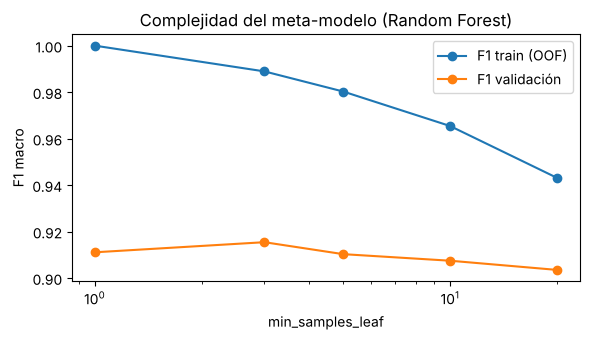

min_samples_leaf escogido: 3


,min_samples_leaf,F1 train (OOF),F1 validación
0,1,1.0000,0.9111
1,3,0.9889,0.9154
2,5,0.9803,0.9103
3,10,0.9654,0.9075
4,20,0.9431,0.9035


In [14]:
filas = []
for leaf in [1, 3, 5, 10, 20]:
    stack.meta_.set_params(min_samples_leaf=leaf).fit(stack.X_meta_train_, y_train)
    filas.append({"min_samples_leaf": leaf,
                  "F1 train (OOF)": f1_score(y_train, stack.meta_.predict(stack.X_meta_train_), average="macro"),
                  "F1 validación": f1_score(y_val, stack.predict(X_val), average="macro")})
res_leaf = pd.DataFrame(filas)
mejor_leaf = int(res_leaf.loc[res_leaf["F1 validación"].idxmax(), "min_samples_leaf"])
stack.meta_.set_params(min_samples_leaf=mejor_leaf).fit(stack.X_meta_train_, y_train)
stack.leaf_meta = mejor_leaf

ax = res_leaf.plot(x="min_samples_leaf", y=["F1 train (OOF)", "F1 validación"], marker="o", logx=True, figsize=(6, 3.5))
ax.set_title("Complejidad del meta-modelo (Random Forest)"); ax.set_ylabel("F1 macro")
plt.tight_layout(); plt.show()
print("min_samples_leaf escogido:", mejor_leaf)
res_leaf.round(4)

**Qué sale:** con hojas de 1 reseña el meta‑modelo memoriza (F1 de entrenamiento ≈ 1) y valida peor; con hojas grandes se simplifica de más. El mejor punto está en hojas pequeñas pero no mínimas.

## 5. Evaluación del modelo final en validación

Accuracy: 0.9113 | F1 macro: 0.9154

              precision    recall  f1-score   support

    negativo     0.8760    0.8802    0.8781       843
     neutral     0.9944    0.9930    0.9937       715
    positivo     0.8760    0.8729    0.8745       842

    accuracy                         0.9113      2400
   macro avg     0.9155    0.9154    0.9154      2400
weighted avg     0.9113    0.9113    0.9113      2400



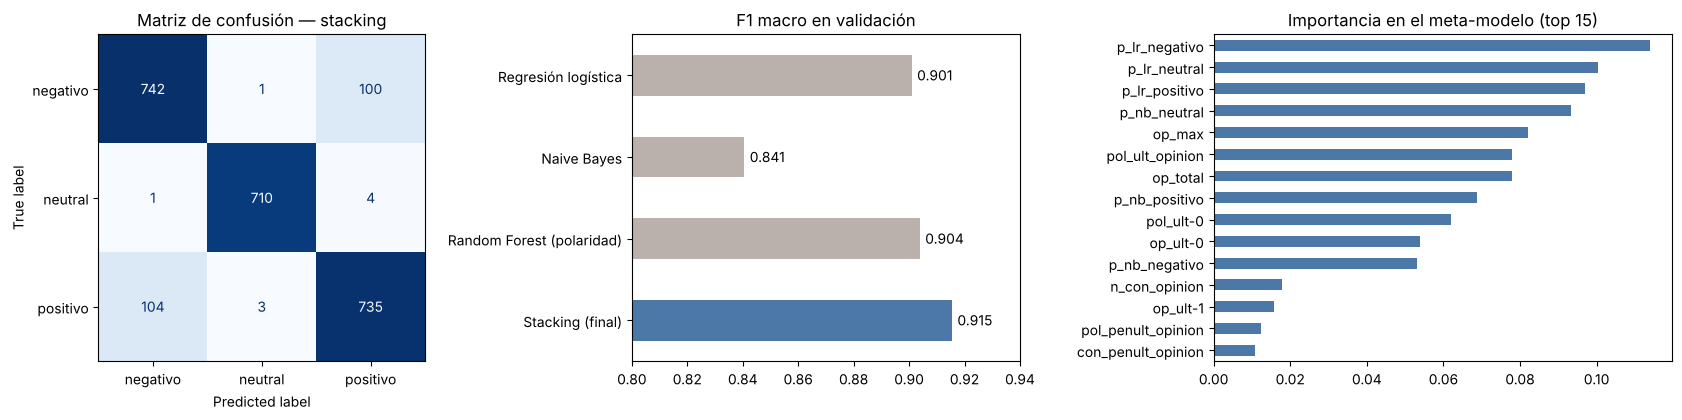

In [15]:
pred_stack = stack.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, pred_stack):.4f} | F1 macro: {f1_score(y_val, pred_stack, average='macro'):.4f}\n")
print(classification_report(y_val, pred_stack, digits=4))

resumen = pd.concat([res_base["F1 macro"], pd.Series({"Stacking (final)": f1_score(y_val, pred_stack, average="macro")})])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={"width_ratios": [1, 1.1, 1.3]})
ConfusionMatrixDisplay.from_predictions(y_val, pred_stack, labels=ORDER, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión — stacking")
resumen.plot(kind="barh", ax=axes[1], color=["#BAB0AC"] * 3 + ["#4C78A8"])
axes[1].set_xlim(0.8, 0.94); axes[1].set_title("F1 macro en validación"); axes[1].invert_yaxis()
for i, v in enumerate(resumen.values):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center")
imp = pd.Series(stack.meta_.feature_importances_, index=stack.nombres_meta()).sort_values().tail(15)
imp.plot(kind="barh", ax=axes[2], color="#4C78A8"); axes[2].set_title("Importancia en el meta-modelo (top 15)")
plt.tight_layout(); plt.show()

**Qué sale:**
- **Matriz de confusión:** `neutral` sigue casi perfecta. Los errores entre `positivo` y `negativo` bajan frente a cualquier modelo individual.
- **F1 macro:** el *stacking* supera a los tres modelos base.
- **Importancia:** el meta‑modelo usa sobre todo las probabilidades de LR y NB, seguidas por las variables de opinión y la polaridad de la última cláusula con opinión. Las variables de **conector** tienen importancia baja. Su aporte principal es indirecto: separar en cláusulas hace que "la última cláusula" sea la opinión correcta. Si en una versión futura hay que simplificar el modelo, son las primeras candidatas a quitar.

### 5.1 Control de robustez: ¿la mejora depende de la partición?

Una diferencia de 1 punto puede ser suerte de la partición. Repetimos el experimento con **otras 3 semillas** de partición train/validación y comparamos el ensamble contra la regresión logística sola, el mejor modelo individual sobre texto.

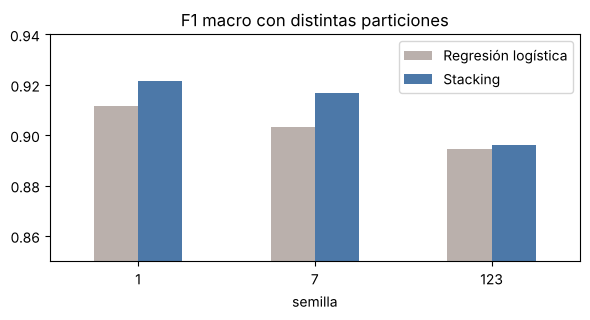

,Regresión logística,Stacking
semilla,,
1,0.9116,0.9215
7,0.9034,0.9166
123,0.8945,0.8961
promedio,0.9032,0.9114


In [16]:
filas = []
for seed in [1, 7, 123]:
    Xa, Xb, ya, yb = train_test_split(train_df["text"], train_df["label"], test_size=0.2,
                                      stratify=train_df["label"], random_state=seed)
    f_lr = f1_score(yb, modelo_lr().fit(Xa, ya).predict(Xb), average="macro")
    f_st = f1_score(yb, StackingPolaridad(leaf_meta=mejor_leaf).fit(Xa, ya).predict(Xb), average="macro")
    filas.append({"semilla": seed, "Regresión logística": f_lr, "Stacking": f_st})
rob = pd.DataFrame(filas).set_index("semilla")
rob.loc["promedio"] = rob.mean()
ax = rob.drop("promedio").plot(kind="bar", rot=0, figsize=(6, 3.3), color=["#BAB0AC", "#4C78A8"], ylim=(0.85, 0.94))
ax.set_title("F1 macro con distintas particiones"); plt.tight_layout(); plt.show()
rob.round(4)

**Qué sale:** en promedio el *stacking* supera a la regresión logística, aunque la ganancia varía según la partición (en alguna es casi nula). Lo reportamos tal cual: la mejora es real pero moderada, del orden de 1 punto, y el resultado esperado en Kaggle está alrededor de 0.91.

## 6. Modelo final, submission y guardado

Reentrenamos el *stacking* con **todo** `train.csv` y predecimos `eval.csv`. El modelo se guarda comprimido con `joblib`.

**Para cargar el `.joblib` en otro entorno** hay que ejecutar antes las celdas de las secciones 2, 3.1, 3.2 y 4, que definen las funciones y clases que usa el modelo.

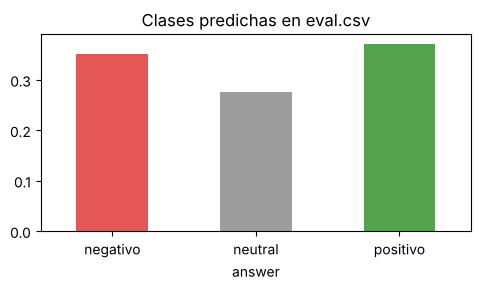

In [17]:
modelo_final = StackingPolaridad(leaf_meta=mejor_leaf, random_state=RANDOM_STATE).fit(train_df["text"], train_df["label"])
submission = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})
assert list(submission.columns) == list(sample_sub.columns) and len(submission) == len(sample_sub)
assert submission["answer"].isin(ORDER).all()
submission.to_csv("submission-G43-5.csv", index=False)

modelo_final.X_meta_train_ = None   # no se necesita para predecir; reduce el tamaño del archivo
joblib.dump(modelo_final, "models/modelo_entrega5_stacking.joblib", compress=3)
assert (joblib.load("models/modelo_entrega5_stacking.joblib").predict(eval_df["text"]) == submission["answer"]).all()

ax = submission["answer"].value_counts(normalize=True).reindex(ORDER).plot(
    kind="bar", rot=0, figsize=(5, 3), color=[COLORS[c] for c in ORDER])
ax.set_title("Clases predichas en eval.csv"); plt.tight_layout(); plt.show()

**Qué sale:** la distribución predicha en `eval.csv` (≈ 35/30/35) coincide con la de entrenamiento. El modelo no colapsa hacia ninguna clase y se recarga desde disco con predicciones idénticas.

## 7. Conclusiones

| Entrega | Enfoque | F1 macro validación |
|---|---|---|
| 1 | TF‑IDF + regresión logística | ≈ 0.75 |
| 2 | + TF‑IDF de la última oración | ≈ 0.89 |
| 3 | BoW binaria + Random Forest | ≈ 0.79 |
| 4 | Random Forest con polaridad por oración | ≈ 0.89 |
| **5** | **Cláusulas + stacking (LR, NB + variables de polaridad → RF)** | **≈ 0.915** |

1. **La representación importó más que el modelo.** El gran salto (0.75 → 0.89) vino de indicarle al modelo **dónde** está la opinión decisiva. Cambiar de clasificador con la misma representación movió el resultado mucho menos.
2. **Cláusulas** refinan esa idea: la opinión que manda puede estar después de un *pero* dentro de la misma oración. Los conectores ayudan a segmentar; como variables directas, aportan poco.
3. **El ensamble funciona porque las fuentes son diversas.** La regresión logística suma evidencia léxica, Naive Bayes tiene otro sesgo y las variables de polaridad describen la estructura. El Random Forest meta aprende cuándo confiar en cada una. Aun siendo el peor modelo individual, NB aporta: sus probabilidades están entre las variables más usadas.
4. **Límite de la Parte 1:** seguimos sin modelar el orden completo de la reseña. Además, el conjunto de datos tiene reseñas cuya etiqueta contradice la regla de "la opinión final manda", lo que pone un techo a cualquier enfoque basado en reglas de posición. Los modelos secuenciales de la Parte 2 deberían capturar esto de forma más general.